# Australian Used Car Market Exploratory Data Analysis

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\jhkan\Documents\Projects\Jaehong-Kang-Project-Repository\Australian Used Car Price Prediction and Market Analysis\clean_used_cars_dataset.csv")

df.head()

,source,make,model,year,kms,price,body_type,transmission,fuel_type,engine_l,drive_type,state,condition,cc,color,seats,car_age
0,raw_1,alfa romeo,romeo 4c,2016,27011,97644.0,convertible,dual_clutch,petrol,1.7,unknown,qld,used,5.5,unknown,5.0,8
1,raw_1,alfa romeo,romeo stelvio,2023,3909,85400.0,suv,automatic,petrol,2.0,unknown,vic,demo,5.5,unknown,5.0,1
2,raw_1,alfa romeo,romeo tonale,2023,22,65250.0,suv,dual_clutch,petrol,1.5,unknown,vic,demo,5.5,unknown,5.0,1
3,raw_1,alfa romeo,romeo tonale,2024,20,75990.0,suv,dual_clutch,petrol,1.5,unknown,vic,new,5.5,unknown,5.0,0
4,raw_1,aston martin,martin rapide,2014,66993,145890.0,hatchback,automatic,petrol,5.9,unknown,nsw,used,12.0,unknown,4.0,10


## 1. Dataset Overview

In [26]:
# Shape of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 52658
Columns: 17


In [27]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52658 entries, 0 to 52657
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   source        52658 non-null  object 
 1   make          52658 non-null  object 
 2   model         52658 non-null  object 
 3   year          52658 non-null  int64  
 4   kms           52658 non-null  int64  
 5   price         52658 non-null  float64
 6   body_type     52658 non-null  object 
 7   transmission  52658 non-null  object 
 8   fuel_type     52658 non-null  object 
 9   engine_l      52658 non-null  float64
 10  drive_type    52658 non-null  object 
 11  state         52658 non-null  object 
 12  condition     52658 non-null  object 
 13  cc            52658 non-null  float64
 14  color         52658 non-null  object 
 15  seats         52658 non-null  float64
 16  car_age       52658 non-null  int64  
dtypes: float64(4), int64(3), object(10)
memory usage: 6.8+ MB


In [29]:
# Summary statistics for numerical variables
df.describe()

,year,kms,price,engine_l,cc,seats,car_age
count,52658.000000,52658.000000,52658.000000,52658.000000,52658.000000,52658.00000,52658.000000
mean,2017.703198,81837.994873,39862.662274,2.394881,1367.971828,5.15407,6.296802
std,5.099404,74213.822897,28709.509234,0.869657,1305.989884,0.99336,5.099404
min,1980.000000,1.000000,900.000000,0.700000,0.000000,2.00000,0.000000
25%,2015.000000,19163.500000,21990.000000,1.995000,4.000000,5.00000,2.000000
50%,2018.000000,66690.000000,33754.000000,2.191000,1598.000000,5.00000,6.000000
75%,2022.000000,122905.250000,48990.000000,2.800000,2199.000000,5.00000,9.000000
max,2024.000000,496608.000000,499990.000000,7.300000,7300.000000,14.00000,44.000000


In [30]:
# Summary statistics for categorical variables
df.describe(include="object")

,source,make,model,body_type,transmission,fuel_type,drive_type,state,condition,color
count,52658,52658,52658,52658,52658,52658,52658,52658,52658,52658
unique,3,73,1034,15,8,6,5,9,3,14
top,raw_1,toyota,ranger,suv,automatic,petrol,fwd,unknown,used,unknown
freq,19719,7912,1967,17484,40076,32131,22186,17236,45527,35731


In [32]:
overview_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Count": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

overview_summary

,Column,Data Type,Non-Null Count,Missing Count,Unique Values
0,source,object,52658,0,3
1,make,object,52658,0,73
2,model,object,52658,0,1034
3,year,int64,52658,0,41
4,kms,int64,52658,0,39226
5,price,float64,52658,0,10141
6,body_type,object,52658,0,15
7,transmission,object,52658,0,8
8,fuel_type,object,52658,0,6
9,engine_l,float64,52658,0,357


## 2. Price Distribution

In [33]:
# Basic price summary
price_summary = df["price"].describe()
price_summary

count     52658.000000
mean      39862.662274
std       28709.509234
min         900.000000
25%       21990.000000
50%       33754.000000
75%       48990.000000
max      499990.000000
Name: price, dtype: float64

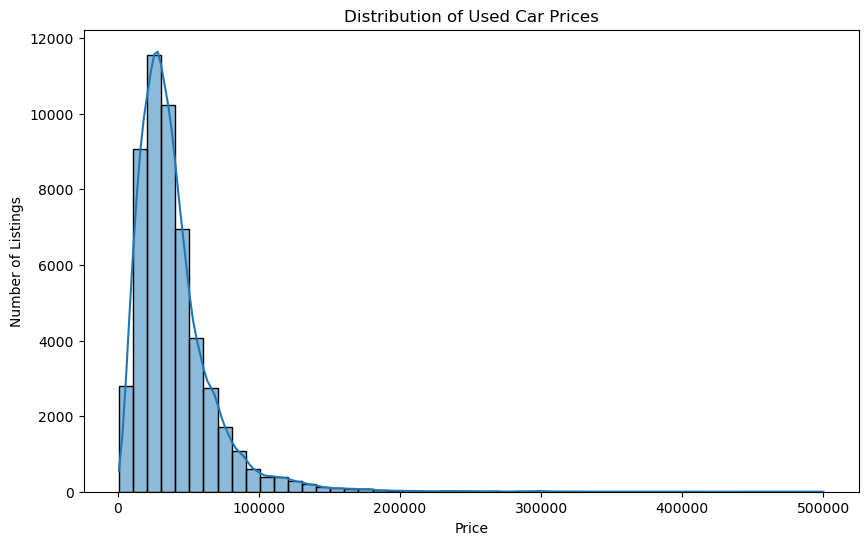

In [35]:
# Price histogram
plt.figure(figsize=(10,6))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

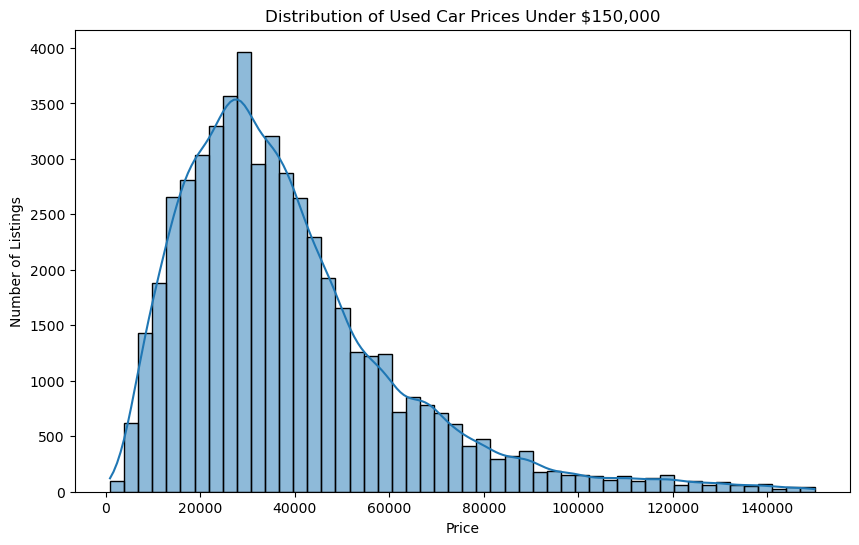

In [36]:
# Price distribution without extreme outliers
plt.figure(figsize=(10,6))
sns.histplot(df[df["price"] < 150000]["price"], bins=50, kde=True)
plt.title("Distribution of Used Car Prices Under $150,000")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

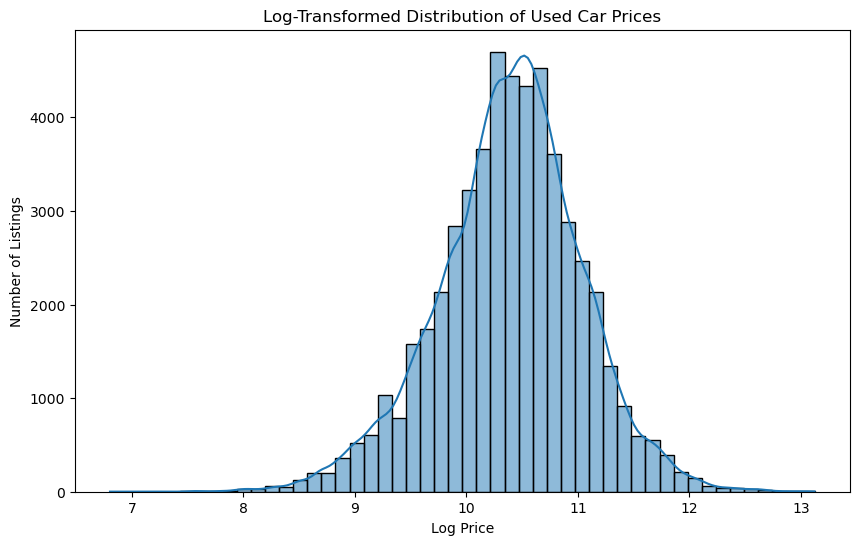

In [37]:
# Log price distribution (Car prices are right skewed)
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10, 6))
sns.histplot(df["log_price"], bins=50, kde=True)
plt.title("Log-Transformed Distribution of Used Car Prices")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")
plt.show()

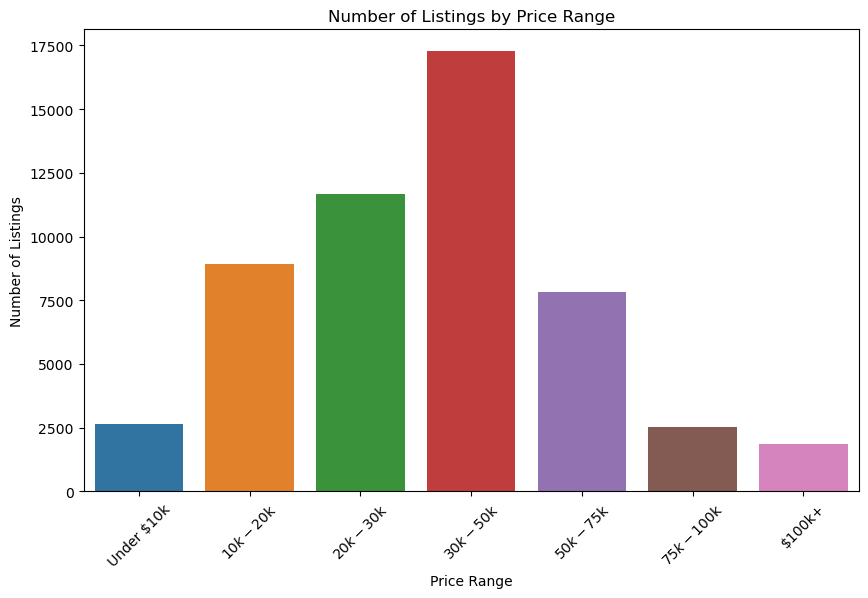

In [43]:
# Price ranges
price_bins = [0, 10000, 20000, 30000, 50000, 75000, 100000, df["price"].max()]
price_labels = [
    "Under $10k",
    "$10k-$20k",
    "$20k-$30k",
    "$30k-$50k",
    "$50k-$75k",
    "$75k-$100k",
    "$100k+"
]

df["price_range"] = pd.cut(df["price"], bins=price_bins, labels=price_labels, include_lowest=True)

price_range_counts = df["price_range"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=price_range_counts.index, y=price_range_counts.values)
plt.title("Number of Listings by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

## 3. Market Composition

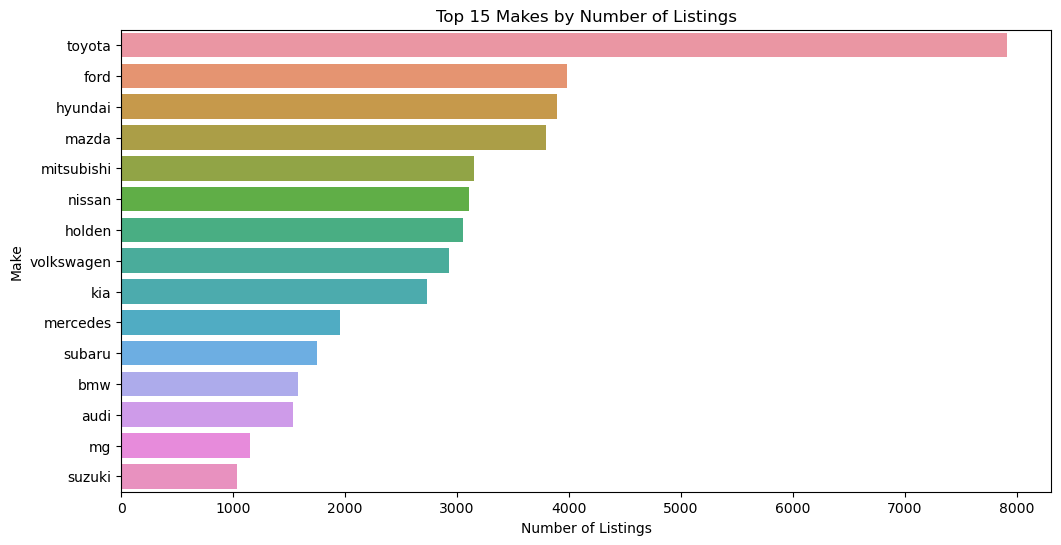

In [40]:
# Top listings by make
top_makes = df["make"].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_makes.values, y=top_makes.index)
plt.title("Top 15 Makes by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Make")
plt.show()

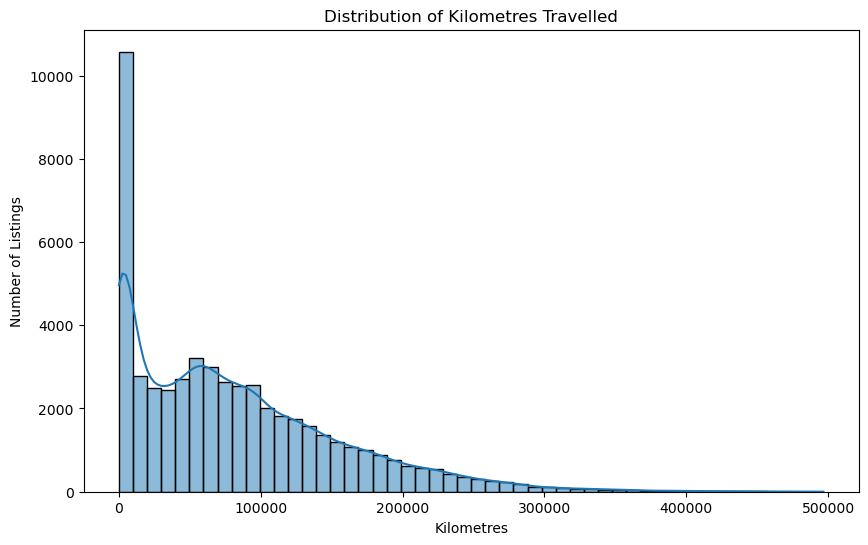

In [55]:
# Listings by Kilometres
plt.figure(figsize=(10,6))
sns.histplot(df["kms"], bins=50, kde=True)
plt.title("Distribution of Kilometres Travelled")
plt.xlabel("Kilometres")
plt.ylabel("Number of Listings")
plt.show()

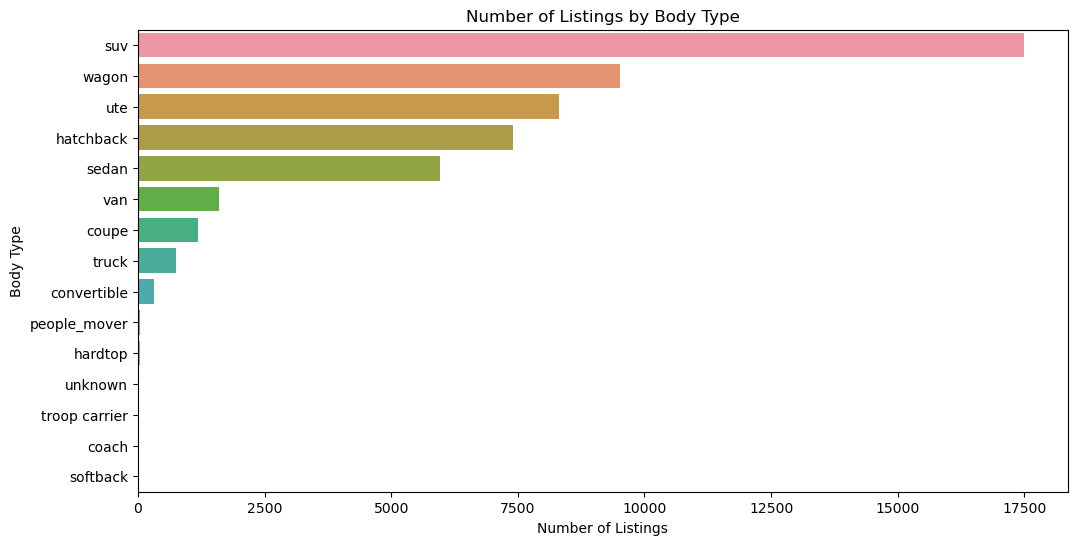

In [42]:
# Listings by body type
body_counts = df["body_type"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=body_counts.values, y=body_counts.index)
plt.title("Number of Listings by Body Type")
plt.xlabel("Number of Listings")
plt.ylabel("Body Type")
plt.show()

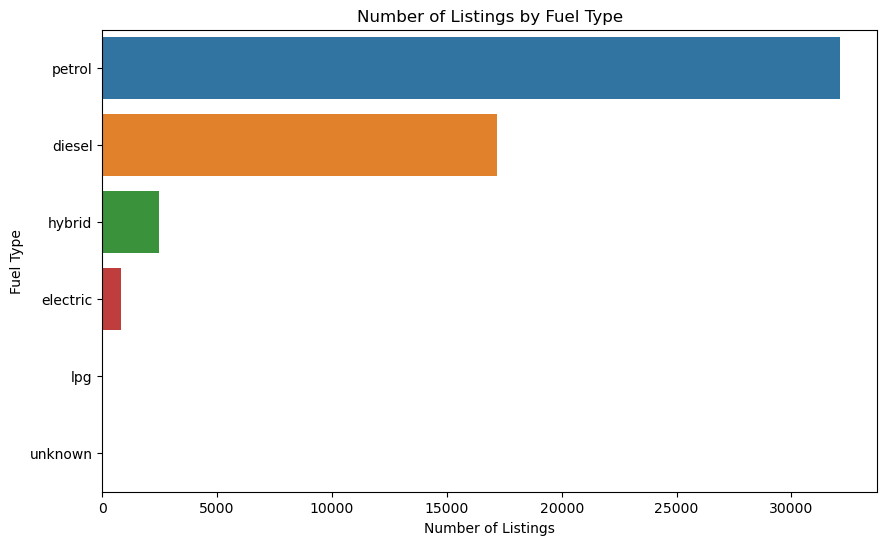

In [44]:
# Listings by fuel type
fuel_counts = df["fuel_type"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=fuel_counts.values, y=fuel_counts.index)
plt.title("Number of Listings by Fuel Type")
plt.xlabel("Number of Listings")
plt.ylabel("Fuel Type")
plt.show()

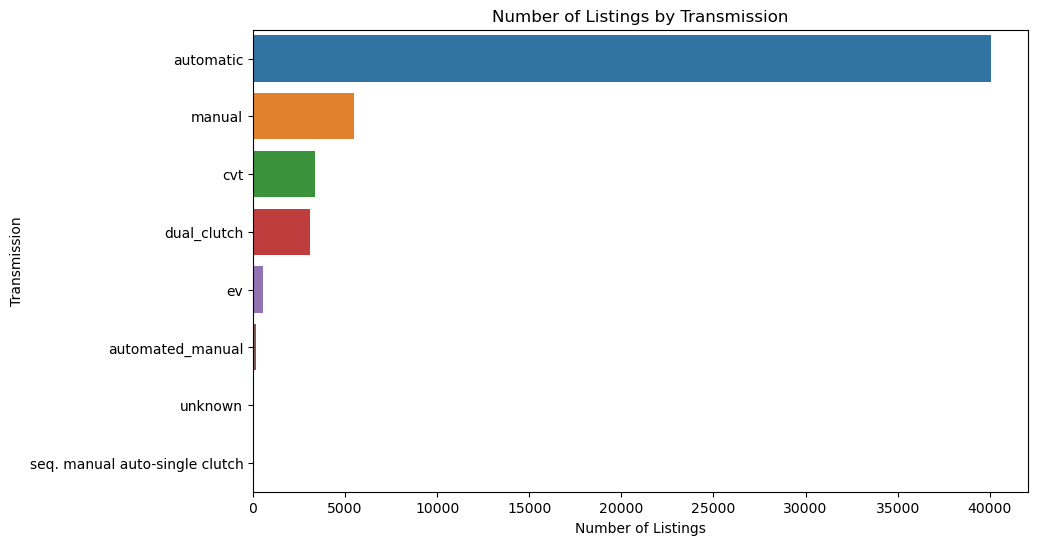

In [45]:
# Listings by transmission
transmission_counts = df["transmission"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=transmission_counts.values, y=transmission_counts.index)
plt.title("Number of Listings by Transmission")
plt.xlabel("Number of Listings")
plt.ylabel("Transmission")
plt.show()

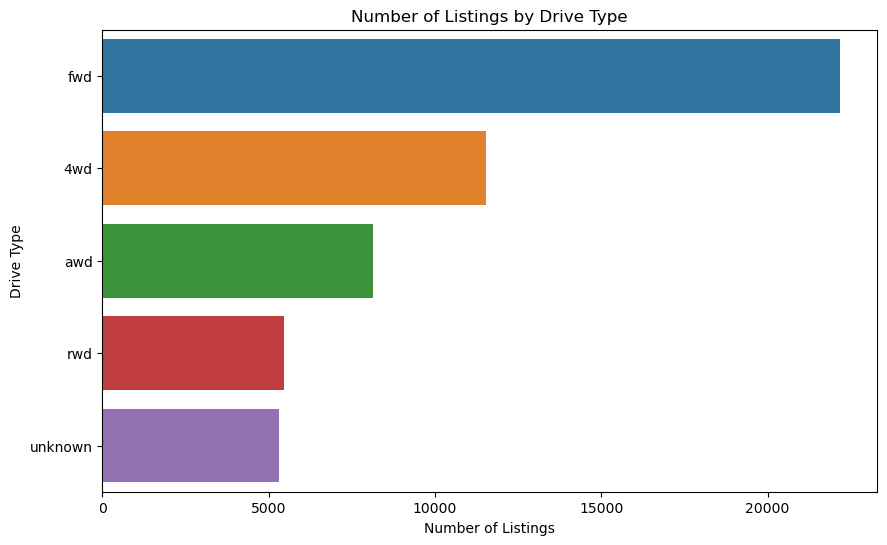

In [46]:
# Listings by drive type
drive_counts = df["drive_type"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=drive_counts.values, y=drive_counts.index)
plt.title("Number of Listings by Drive Type")
plt.xlabel("Number of Listings")
plt.ylabel("Drive Type")
plt.show()

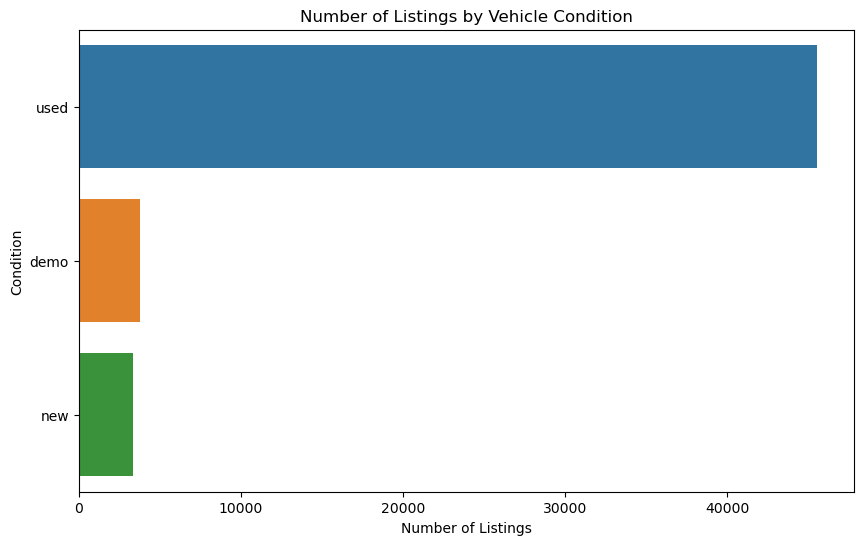

In [47]:
# Listings vby condition
condition_counts = df["condition"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=condition_counts.values, y=condition_counts.index)
plt.title("Number of Listings by Vehicle Condition")
plt.xlabel("Number of Listings")
plt.ylabel("Condition")
plt.show()

## 4. Price by Vehicle Characteristics

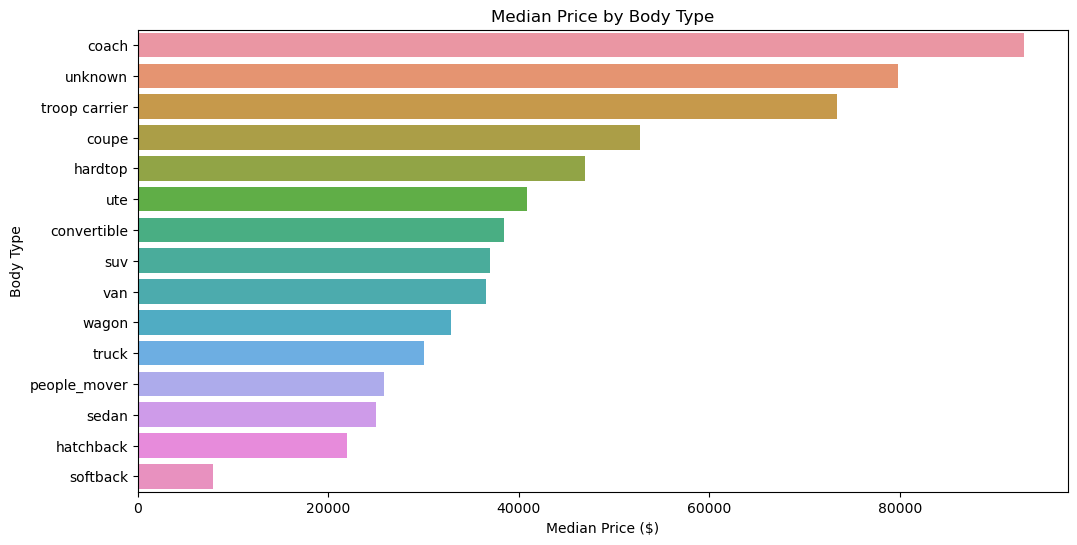

In [49]:
# Median price by body type
body_price = df.groupby("body_type").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean")
).sort_values("median_price", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=body_price.reset_index(), x="median_price", y="body_type")
plt.title("Median Price by Body Type")
plt.xlabel("Median Price ($)")
plt.ylabel("Body Type")
plt.show()

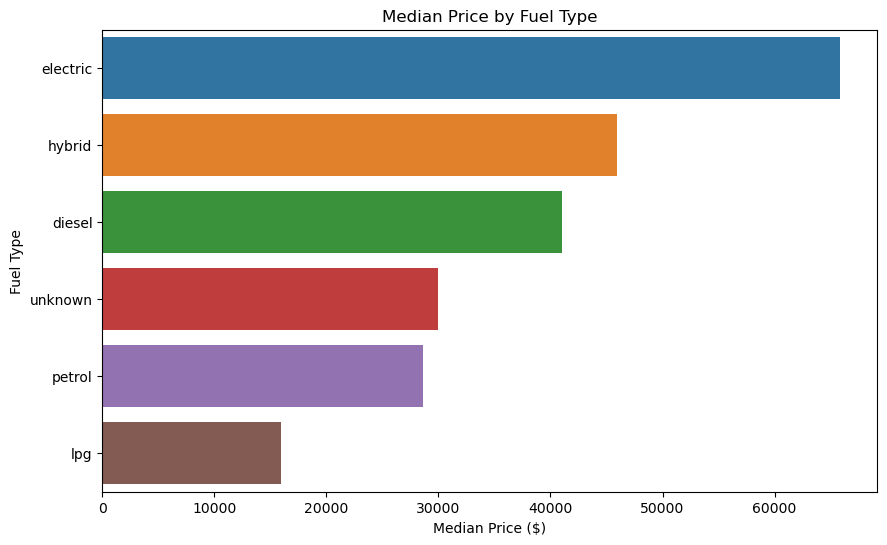

In [51]:
# Median price by fuel type
fuel_price = df.groupby("fuel_type").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean"),
    average_kms=("kms", "mean"),
    average_age=("car_age", "mean")
).sort_values("median_price", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fuel_price.reset_index(), x="median_price", y="fuel_type")
plt.title("Median Price by Fuel Type")
plt.xlabel("Median Price ($)")
plt.ylabel("Fuel Type")
plt.show()

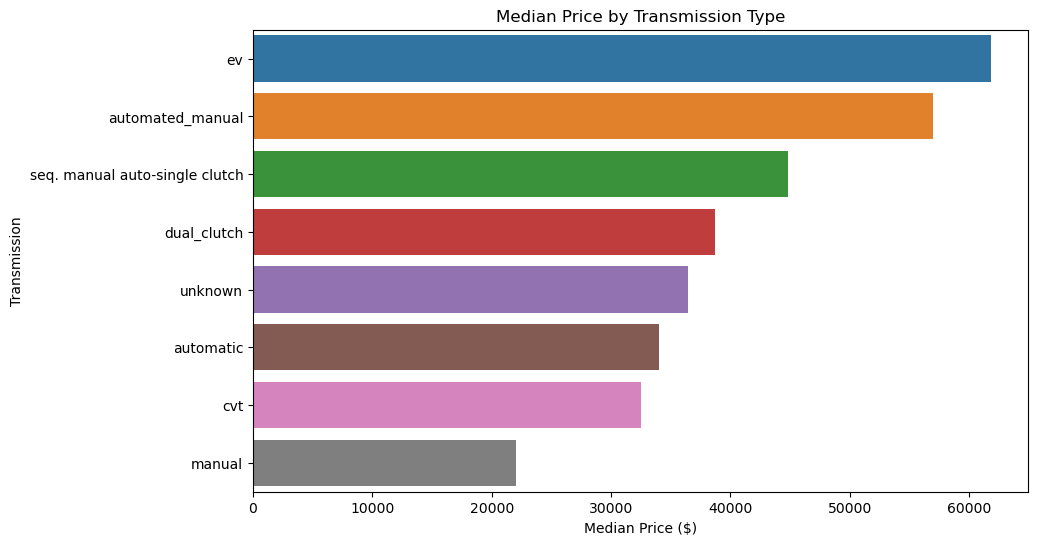

In [52]:
# Median price by transmission
transmission_price = df.groupby("transmission").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean"),
    average_kms=("kms", "mean"),
    average_age=("car_age", "mean")
).sort_values("median_price", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=transmission_price.reset_index(), x="median_price", y="transmission")
plt.title("Median Price by Transmission Type")
plt.xlabel("Median Price ($)")
plt.ylabel("Transmission")
plt.show()

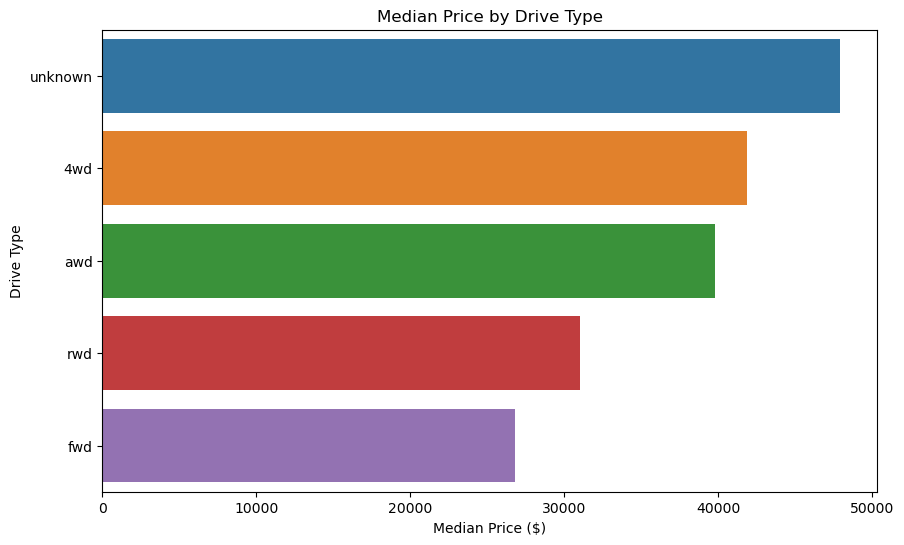

In [53]:
# Median price by drive type
drive_price = df.groupby("drive_type").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean")
).sort_values("median_price", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=drive_price.reset_index(), x="median_price", y="drive_type")
plt.title("Median Price by Drive Type")
plt.xlabel("Median Price ($)")
plt.ylabel("Drive Type")
plt.show()

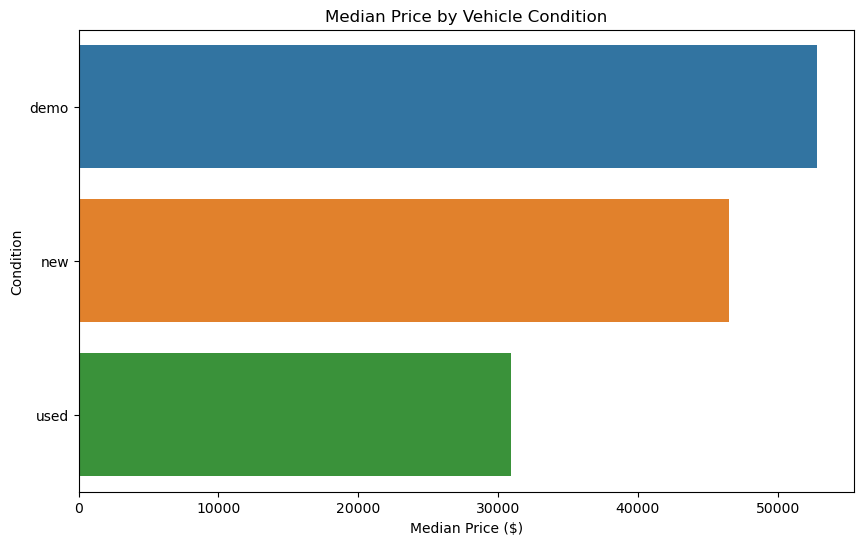

In [54]:
# Median price by condition
condition_price = df.groupby("condition").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean"),
    average_kms=("kms", "mean"),
    average_age=("car_age", "mean")
).sort_values("median_price", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=condition_price.reset_index(), x="median_price", y="condition")
plt.title("Median Price by Vehicle Condition")
plt.xlabel("Median Price ($)")
plt.ylabel("Condition")
plt.show()

## 5. Relationship Between Price and Other Variables

In [56]:
# Correlation with price
numeric_cols = ["price", "year", "kms", "engine_l", "cc", "seats", "car_age"]

corr_matrix = df[numeric_cols].corr()

corr_matrix["price"].sort_values(ascending=False)

price       1.000000
year        0.460324
engine_l    0.342522
cc          0.153861
seats       0.076746
kms        -0.459060
car_age    -0.460324
Name: price, dtype: float64

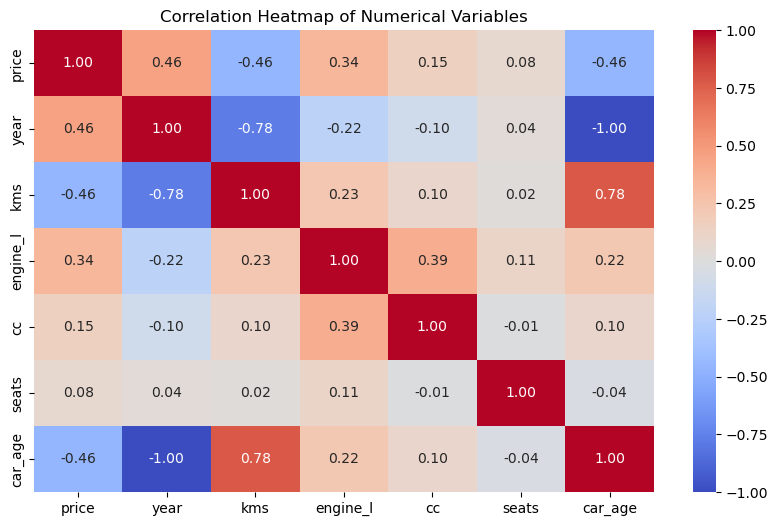

In [57]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

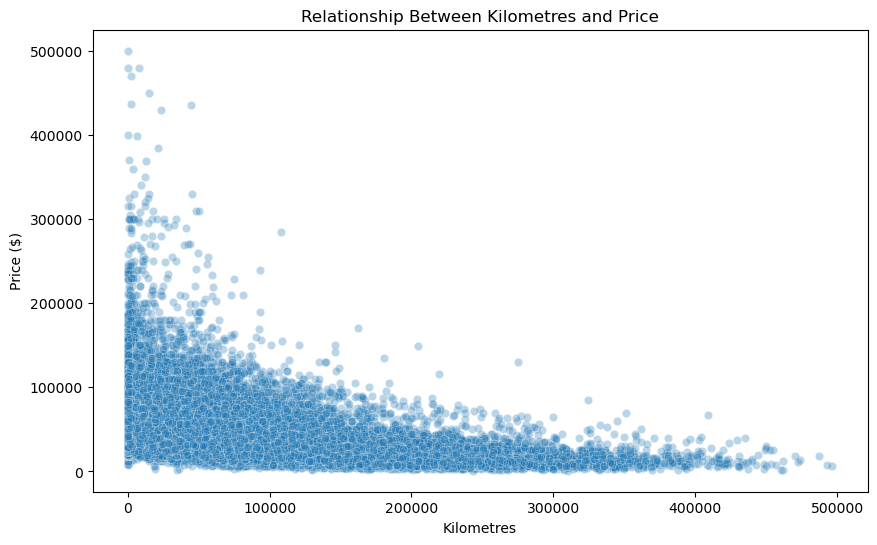

In [58]:
# Price vs kilometres
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="kms", y="price", alpha=0.3)
plt.title("Relationship Between Kilometres and Price")
plt.xlabel("Kilometres")
plt.ylabel("Price ($)")
plt.show()

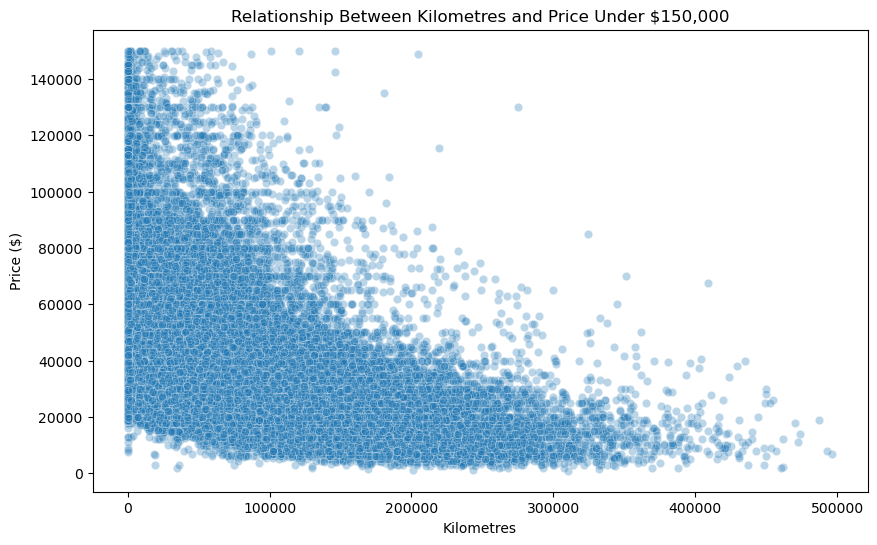

In [59]:
# Price vs kilometres excluding extreme prices
df_price_filtered = df[df["price"] < 150000]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_filtered, x="kms", y="price", alpha=0.3)
plt.title("Relationship Between Kilometres and Price Under $150,000")
plt.xlabel("Kilometres")
plt.ylabel("Price ($)")
plt.show()

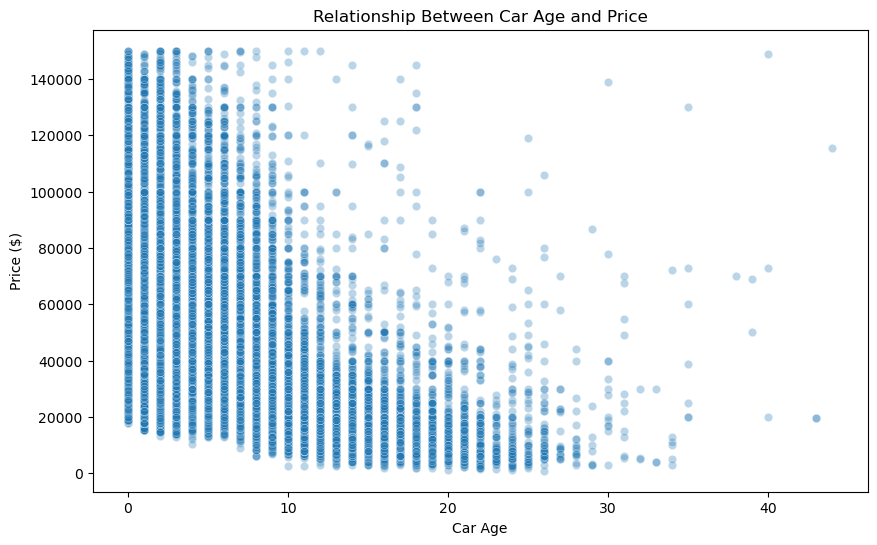

In [60]:
# Price vs car age
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_filtered, x="car_age", y="price", alpha=0.3)
plt.title("Relationship Between Car Age and Price")
plt.xlabel("Car Age")
plt.ylabel("Price ($)")
plt.show()

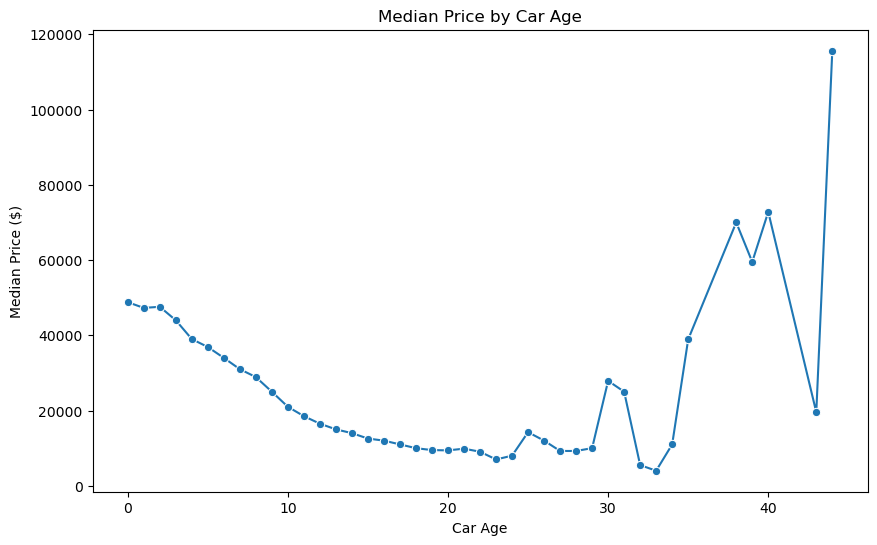

In [62]:
# Median price by car age
age_price = df.groupby("car_age").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean")
).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_price, x="car_age", y="median_price", marker="o")
plt.title("Median Price by Car Age")
plt.xlabel("Car Age")
plt.ylabel("Median Price ($)")
plt.show()

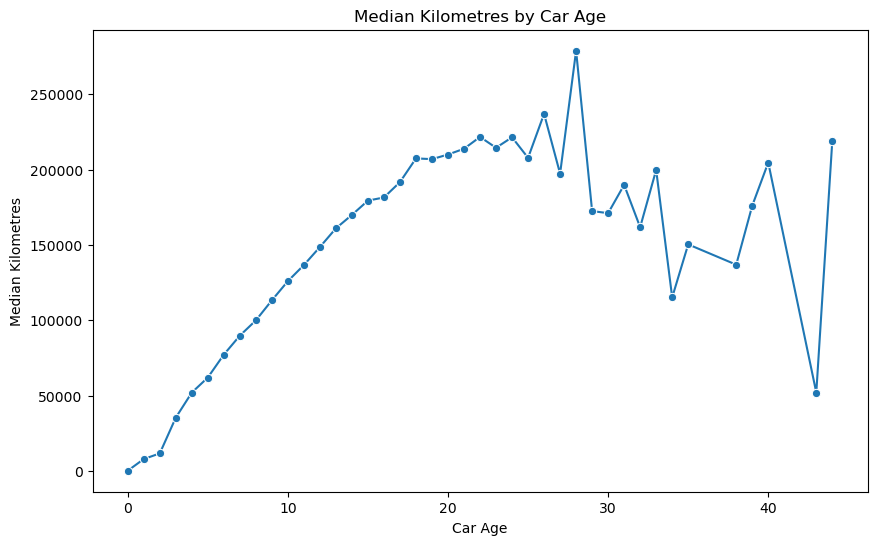

In [63]:
# Median kilometres by car age
age_kms = df.groupby("car_age").agg(
    median_kms=("kms", "median"),
    average_kms=("kms", "mean")
).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_kms, x="car_age", y="median_kms", marker="o")
plt.title("Median Kilometres by Car Age")
plt.xlabel("Car Age")
plt.ylabel("Median Kilometres")
plt.show()

## 6. Brand and Model Analysis

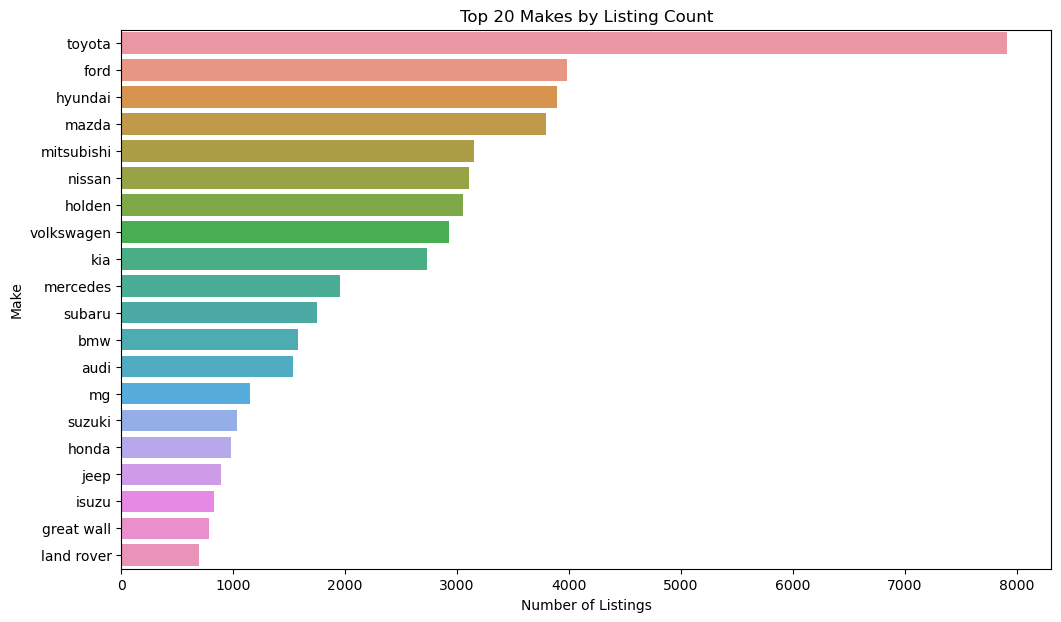

In [65]:
# Top makes by listing count
top_makes = df["make"].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_makes.values, y=top_makes.index)
plt.title("Top 20 Makes by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Make")
plt.show()

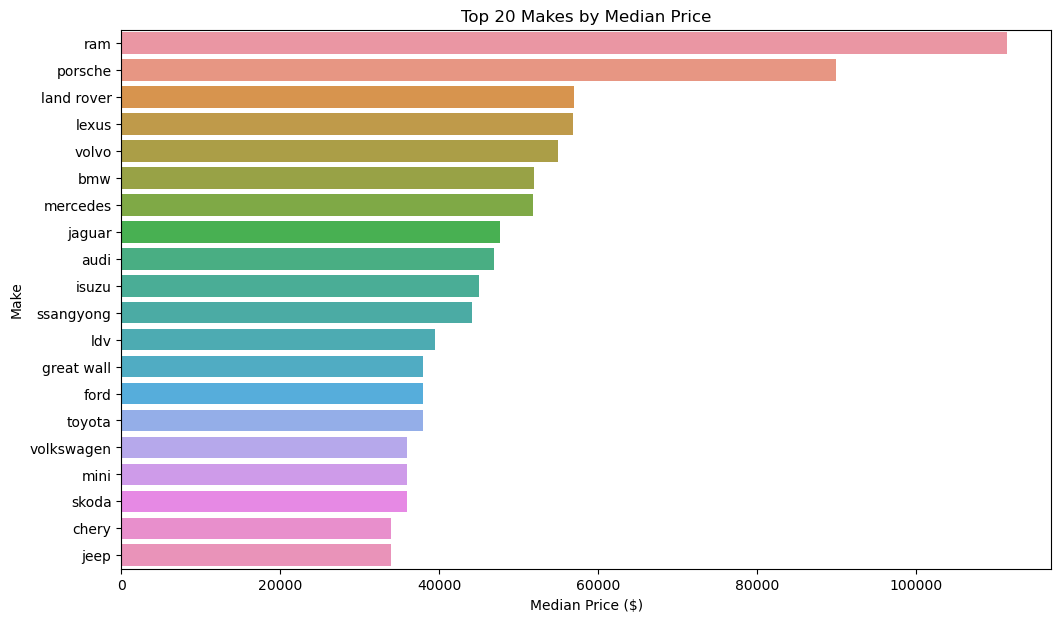

In [66]:
# Median price by make
make_price = df.groupby("make").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean"),
    average_kms=("kms", "mean"),
    average_age=("car_age", "mean")
).reset_index()

make_price_filtered = make_price[make_price["listings"] >= 100].sort_values("median_price", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=make_price_filtered.head(20), x="median_price", y="make")
plt.title("Top 20 Makes by Median Price")
plt.xlabel("Median Price ($)")
plt.ylabel("Make")
plt.show()

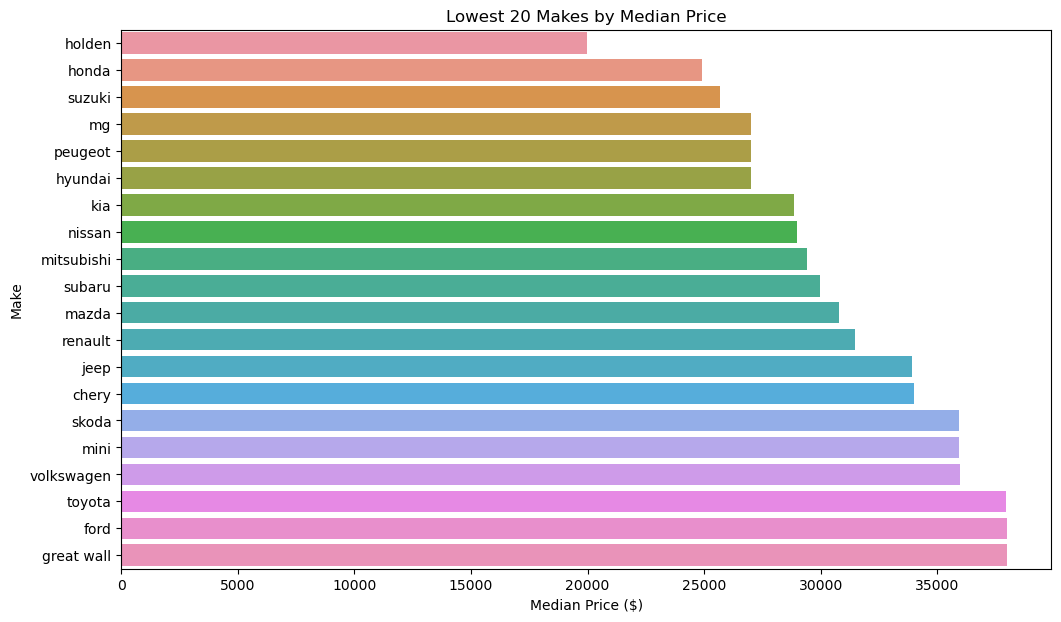

In [67]:
# Most affordable makes by median price
make_price_filtered.sort_values("median_price", ascending=True).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(data=make_price_filtered.sort_values("median_price").head(20), x="median_price", y="make")
plt.title("Lowest 20 Makes by Median Price")
plt.xlabel("Median Price ($)")
plt.ylabel("Make")
plt.show()

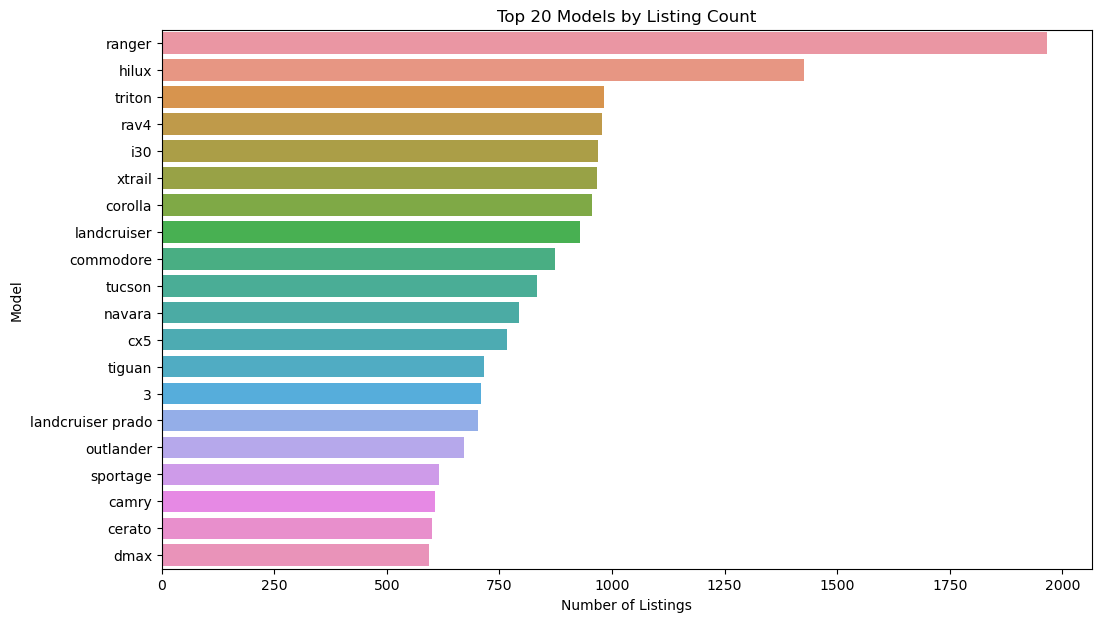

In [68]:
# Top models by listing count
top_models = df["model"].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_models.values, y=top_models.index)
plt.title("Top 20 Models by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Model")
plt.show()

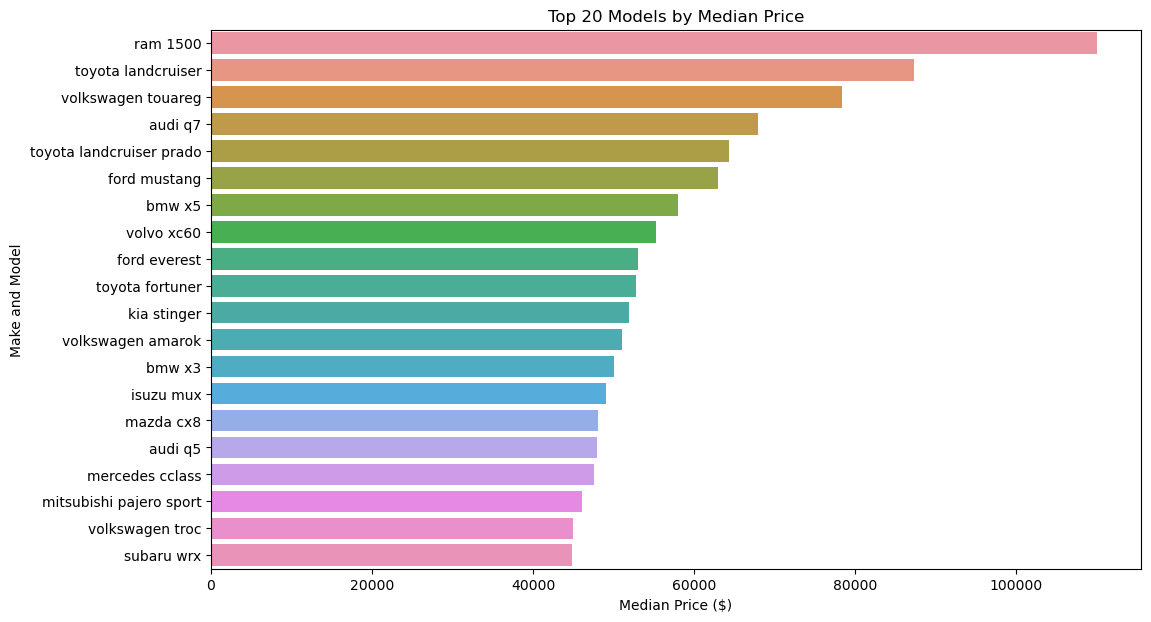

In [70]:
# Median price by model
model_price = df.groupby(["make", "model"]).agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean"),
    average_kms=("kms", "mean"),
    average_age=("car_age", "mean")
).reset_index()

model_price_filtered = model_price[model_price["listings"] >= 100].sort_values("median_price", ascending=False)
model_price_filtered["make_model"] = model_price_filtered["make"] + " " + model_price_filtered["model"]

plt.figure(figsize=(12, 7))
sns.barplot(data=model_price_filtered.head(20), x="median_price", y="make_model")
plt.title("Top 20 Models by Median Price")
plt.xlabel("Median Price ($)")
plt.ylabel("Make and Model")
plt.show()

## 7. State/Location Analysis

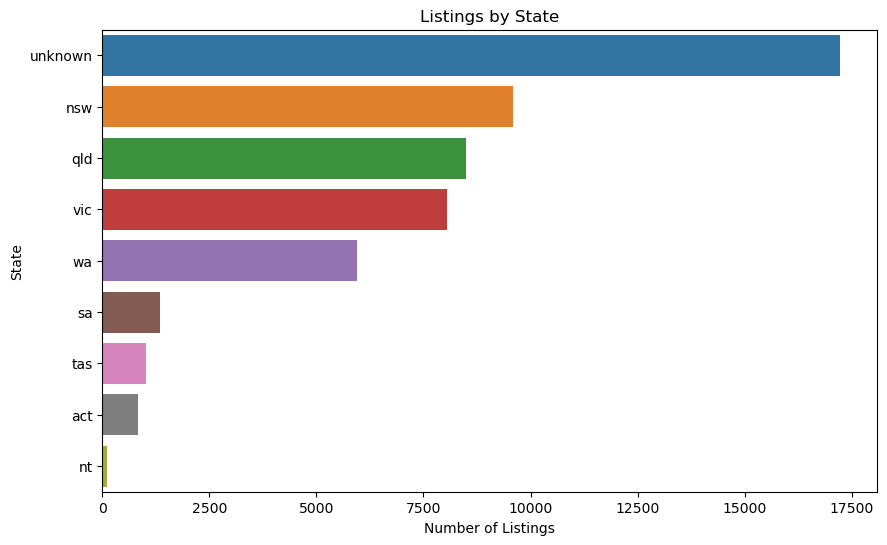

In [24]:
state_counts = df["state"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=state_counts.values, y=state_counts.index)
plt.title("Listings by State")
plt.xlabel("Number of Listings")
plt.ylabel("State")
plt.show()

In [25]:
known_states = df[df["state"] != "unknown"]

state_price = known_states.groupby("state").agg(
    listings=("price", "count"),
    median_price=("price", "median"),
    average_price=("price", "mean")
).sort_values("median_price", ascending=False)

state_price

,listings,median_price,average_price
state,,,
wa,5957,37490.0,44205.910190
vic,8061,36490.0,43516.717901
tas,1023,36040.0,40383.653959
qld,8495,34382.0,38400.330783
nsw,9584,32999.0,41570.098915
sa,1339,31130.0,39080.405527
nt,120,30990.0,37904.616667
act,843,30335.0,37365.858837


## 9. Key Insights Summary